In [4]:
# === Cell 1: Load and explore dataset files ===
# Rationale: Before any analysis, we need to understand the data structure.
# - metadata.csv → clinical info per sample (patient, group, age, etc.)
# - seqtab_nochim_export.xlsx → sequence abundance table (ASVs) per sample
# - taxa_species_export.xlsx → taxonomic classification of each ASV
# - README.md → dataset description

import pandas as pd

# Clinical metadata
metadata = pd.read_csv('../data/metadata.csv')
print("=== METADATA ===")
print(f"Shape: {metadata.shape[0]} samples x {metadata.shape[1]} columns")
print(f"\nColumns: {list(metadata.columns)}")
print(f"\n{metadata.head()}")

=== METADATA ===
Shape: 59 samples x 1 columns

Columns: ['SampleID;host_disease;SampleName;DiseaseStatus;Sex;Age']

  SampleID;host_disease;SampleName;DiseaseStatus;Sex;Age
0     SRR29923448;CRC1;CT8;Colorectal cancer;male;76    
1   SRR29923449;CRC2;CA1;Colorectal cancer;female;71    
2            SRR29923450;Healthy1;H5;Healthy;male;58    
3  SRR29923451;Polype1;AP20;Adenomatous Polyps;fe...    
4            SRR29923452;Healthy2;H8;Healthy;male;63    


In [5]:
# === Cell 2: Reload metadata with correct separator ===
# The CSV uses semicolons (;) as delimiter instead of commas.
# We also inspect data types and unique values to understand the clinical groups.

metadata = pd.read_csv('../data/metadata.csv', sep=';')
print("=== METADATA ===")
print(f"Shape: {metadata.shape[0]} samples x {metadata.shape[1]} columns")
print(f"\nColumns: {list(metadata.columns)}")
print(f"\n{metadata.head(10)}")
print(f"\n=== DISEASE GROUPS ===")
print(metadata['DiseaseStatus'].value_counts())
print(f"\n=== SEX DISTRIBUTION ===")
print(metadata['Sex'].value_counts())
print(f"\n=== AGE STATS ===")
print(metadata['Age'].describe())

=== METADATA ===
Shape: 59 samples x 6 columns

Columns: ['SampleID', 'host_disease', 'SampleName', 'DiseaseStatus', 'Sex', 'Age']

      SampleID host_disease SampleName       DiseaseStatus     Sex  Age
0  SRR29923448         CRC1        CT8   Colorectal cancer    male   76
1  SRR29923449         CRC2        CA1   Colorectal cancer  female   71
2  SRR29923450     Healthy1         H5             Healthy    male   58
3  SRR29923451      Polype1       AP20  Adenomatous Polyps  female   69
4  SRR29923452     Healthy2         H8             Healthy    male   63
5  SRR29923453     Healthy3         H9             Healthy    male   76
6  SRR29923454     Healthy4        H10             Healthy  female   79
7  SRR29923455     Healthy5        H11             Healthy  female   79
8  SRR29923456      Polype2      APA13  Adenomatous Polyps    male   54
9  SRR29923457     Healthy6         H7             Healthy    male   58

=== DISEASE GROUPS ===
DiseaseStatus
Colorectal cancer     21
Healthy      

In [6]:
# === Cell 3: Load ASV abundance table and taxonomy ===
# Rationale: The core of microbiome analysis is the abundance table (samples x ASVs)
# and the taxonomy table (ASV → Kingdom, Phylum, ..., Species).
# We need to understand their dimensions and structure before merging them.

# ASV abundance table: rows = ASVs, columns = samples (usually)
asv_table = pd.read_excel('../data/seqtab_nochim_export.xlsx')
print("=== ASV ABUNDANCE TABLE ===")
print(f"Shape: {asv_table.shape}")
print(f"Columns (first 5): {list(asv_table.columns[:5])}")
print(f"\n{asv_table.iloc[:5, :5]}")

print("\n")

# Taxonomy table: maps each ASV to its taxonomic classification
taxonomy = pd.read_excel('../data/taxa_species_export.xlsx')
print("=== TAXONOMY TABLE ===")
print(f"Shape: {taxonomy.shape}")
print(f"Columns: {list(taxonomy.columns)}")
print(f"\n{taxonomy.head()}")

=== ASV ABUNDANCE TABLE ===
Shape: (59, 6694)
Columns (first 5): ['Unnamed: 0', 'CCTACGGGAGGCAGCAGTGATTAACCTTTAGCAATAAACGAAAGTTTAACTAAGCTATACTAACCCCAGGGTTGGTCAATTTCGTGCCAGCCACCGCGGTCACACGATTAACCCAAGTCAATAGAAGCCGGCGTAAAGAGTGTTTTAGATCACCCCCTCCCCAATAAAGCTAAAACTCACCTGAGTTGTAAAAAACTCCAGTTGACACAAAATAGACTACGAAAGTGGCTTTAACATATCTGAACACACAATAGCTAAGACCCAAACTGGGATTAGATACCCTGGTAGTC', 'CCTACGGGAGGCAGCAGTGGGGAATATTGCACAATGGGGGAAACCCTGATGCAGCGACGCCGCGTGAGCGAAGAAGTATTTCGGTATGTAAAGCTCTATCAGCAGGGAAGAAAATGACGGTACCTGACTAAGAAGCACCGGCTAAATACGTGCCAGCAGCCGCGGTAATACGTATGGTGCAAGCGTTATCCGGATTTACTGGGTGTAAAGGGAGCGTAGACGGATGGGCAAGTCTGATGTGAAAACCCGGGGCTCAACCCCGGGACTGCATTGGAAACTGTTCATCTAGAGTGCTGGAGAGGTAAGTGGAATTCCTAGTGTAGCGGTGAAATGCGTAGATATTAGGAGGAACACCAGTGGCGAAGGCGGCTTACTGGACAGTAACTGACGTTGAGGCTCGAAAGCGTGGGGAGCAAACAGGATTAGATACCCTGGTAGTC', 'CCTACGGGAGGCAGCAGTGATTAACCTTTAGCAATAAACGAAAGTTTAACTAAGCTATACTAACCCCAGGGTTGGTCAATTTCGTGCCAGCCACCGCGGTCACACGATTAACCCAAGTCAATAGAAGCCGGCGTAAAGAGTGTTTTAGATCACCCCCTCCCCAATAAAGCTAAAACTCACC

In [7]:
# === Cell 4: Clean column names and verify table alignment ===
# Rationale: Both tables use DNA sequences as identifiers.
# The ASV table has sequences as column names, the taxonomy table has them as rows.
# We need to:
# 1. Rename the 'Unnamed: 0' columns to meaningful names
# 2. Check that the ASV IDs match between both tables
# 3. Set proper indices for easier merging later

# Rename identifier columns
asv_table = asv_table.rename(columns={'Unnamed: 0': 'SampleID'})
taxonomy = taxonomy.rename(columns={'Unnamed: 0': 'ASV_sequence'})

# Set SampleID as index for the abundance table
asv_table = asv_table.set_index('SampleID')

print(f"ASV table: {asv_table.shape[0]} samples x {asv_table.shape[1]} ASVs")
print(f"Taxonomy table: {taxonomy.shape[0]} ASVs x {taxonomy.shape[1]} levels")

# Check if ASV sequences match between tables
asv_in_abundance = set(asv_table.columns)
asv_in_taxonomy = set(taxonomy['ASV_sequence'])
shared = asv_in_abundance & asv_in_taxonomy

print(f"\nASVs in abundance table: {len(asv_in_abundance)}")
print(f"ASVs in taxonomy table:  {len(asv_in_taxonomy)}")
print(f"Shared (matched):        {len(shared)}")
print(f"Only in abundance:       {len(asv_in_abundance - asv_in_taxonomy)}")
print(f"Only in taxonomy:        {len(asv_in_taxonomy - asv_in_abundance)}")

ASV table: 59 samples x 6693 ASVs
Taxonomy table: 6693 ASVs x 8 levels

ASVs in abundance table: 6693
ASVs in taxonomy table:  6693
Shared (matched):        6693
Only in abundance:       0
Only in taxonomy:        0


In [8]:
# === Cell 5: Display tables in a readable format ===
# Jupyter can render pandas DataFrames as formatted tables
# instead of raw text. We use .head() to show just the first rows,
# and .style for better readability. We also look at the taxonomy
# distribution to understand what types of bacteria dominate.

from IPython.display import display

# Show abundance table (first 5 samples, first 6 ASVs)
print("=== ASV ABUNDANCE TABLE (subset) ===")
display(asv_table.iloc[:5, :6])

print("\n=== TAXONOMY TABLE (first 10 rows) ===")
display(taxonomy.head(10))

# What phyla are most common?
print("\n=== TOP 10 PHYLA ===")
display(taxonomy['Phylum'].value_counts().head(10))

=== ASV ABUNDANCE TABLE (subset) ===


,CCTACGGGAGGCAGCAGTGATTAACCTTTAGCAATAAACGAAAGTTTAACTAAGCTATACTAACCCCAGGGTTGGTCAATTTCGTGCCAGCCACCGCGGTCACACGATTAACCCAAGTCAATAGAAGCCGGCGTAAAGAGTGTTTTAGATCACCCCCTCCCCAATAAAGCTAAAACTCACCTGAGTTGTAAAAAACTCCAGTTGACACAAAATAGACTACGAAAGTGGCTTTAACATATCTGAACACACAATAGCTAAGACCCAAACTGGGATTAGATACCCTGGTAGTC,CCTACGGGAGGCAGCAGTGGGGAATATTGCACAATGGGGGAAACCCTGATGCAGCGACGCCGCGTGAGCGAAGAAGTATTTCGGTATGTAAAGCTCTATCAGCAGGGAAGAAAATGACGGTACCTGACTAAGAAGCACCGGCTAAATACGTGCCAGCAGCCGCGGTAATACGTATGGTGCAAGCGTTATCCGGATTTACTGGGTGTAAAGGGAGCGTAGACGGATGGGCAAGTCTGATGTGAAAACCCGGGGCTCAACCCCGGGACTGCATTGGAAACTGTTCATCTAGAGTGCTGGAGAGGTAAGTGGAATTCCTAGTGTAGCGGTGAAATGCGTAGATATTAGGAGGAACACCAGTGGCGAAGGCGGCTTACTGGACAGTAACTGACGTTGAGGCTCGAAAGCGTGGGGAGCAAACAGGATTAGATACCCTGGTAGTC,CCTACGGGAGGCAGCAGTGATTAACCTTTAGCAATAAACGAAAGTTTAACTAAGCTATACTAACCCCAGGGTTGGTCAATTTCGTGCCAGCCACCGCGGTCACACGATTAACCCAAGTCAATAGAAGCCGGCGTAAAGAGTGTTTTAGATCACCCCCTCCCCAATAAAGCTAAAACTCACCTGAGTTGTAAAAAACTCCAGTTGACACAAAATAGACTACGAAAGTGGCTTTAACATATCTGAACACACAATAGCTAAGACCCAAACTGGGATTAGATACCCGGGTAGTC,CCTACGGGAGGCAGCAGTGGGGAATATTGCACAATGGGGGAAACCCTGATGCAGCAACGCCGCGTGAGTGATGACGGCCTTCGGGTTGTAAAGCTCTGTCTTCAGGGACGATAATGACGGTACCTGAGGAGGAAGCCACGGCTAACTACGTGCCAGCAGCCGCGGTAATACGTAGGTGGCGAGCGTTGTCCGGATTTACTGGGCGTAAAGGGAGCGTAGGCGGACTTTTAAGTGAGATGTGAAATACCCGGGCTCAACTTGGGTGCTGCATTTCAAACTGGAAGTCTAGAGTGCAGGAGAGGAGAATGGAATTCCTAGTGTAGCGGTGAAATGCGTAGAGATTAGGAAGAACACCAGTGGCGAAGGCGATTCTCTGGACTGTAACTGACGCTGAGGCTCGAAAGCGTGGGGAGCAAACAGGATTAGATACCCTGGTAGTC,CCTACGGGAGGCAGCAGTGGGGAATATTGCACAATGGGGGAAACCCTGATGCAGCGACGCCGCGTGAGCGAAGAAGTATTTCGGTATGTAAAGCTCTATCAGCAGGGAAGAAGAAATGACGGTACCTGACTAAGAAGCACCGGCTAAATACGTGCCAGCAGCCGCGGTAATACGTATGGTGCAAGCGTTATCCGGATTTACTGGGTGTAAAGGGAGCGCAGGCGGAAGGCTAAGTCTGATGTGAAAGCCCGGGGCTCAACCCCGGTACTGCATTGGAAACTGGTCATCTAGAGTGTCGGAGGGGTAAGTGGAATTCCTAGTGTAGCGGTGAAATGCGTAGATATTAGGAGGAACACCAGTGGCGAAGGCGGCTTACTGGACGATAACTGACGCTGAGGCTCGAAAGCGTGGGGAGCAAACAGGATTAGATACCCTGGTAGTC,CCTACGGGAGGCAGCAGTGGGGAATATTGCACAATGGGGGAAACCCTGATGCAGCGACGCCGCGTGAGCGAAGAAGTATTTCGGTATGTAAAGCTCTATCAGCAGGGAAGAAAATGACGGTACCTGACTAAGAAGCACCGGCTAAATACGTGCCAGCAGCCGCGGTAATACGTATGGTGCAAGCGTTATCCGGATTTACTGGGTGTAAAGGGAGCGTAGACGGATGGGCAAGTCTGATGTGAAAACCCGGGGCTCAACCCCGGGACTGCATTGGAAACTGTTCATCTAGAGTGCTGGAGAGGTAAGTGGAATTCCTAGTGTAGCGGTGAAATGCGTAGATATTAGGAGGAACACCAGTGGCGAAGGCGGCTTACTGGACAGTAACTGACGTTGAGGCTCGAAAGCGTGGGGAGCAAACAGGATTAGATACCCGGGTAGTC
SampleID,,,,,,
CRC1,34,0,20,0,76,0
CRC10,58,25,0,0,0,11
CRC11,176,48,153,0,40,0
CRC12,0,113,73,0,49,71
CRC13,0,0,34,0,69,0



=== TAXONOMY TABLE (first 10 rows) ===


,ASV_sequence,Kingdom,Phylum,Class,Order,Family,Genus,Species
0,CCTACGGGAGGCAGCAGTGATTAACCTTTAGCAATAAACGAAAGTT...,Bacteria,Proteobacteria,Alphaproteobacteria,Rickettsiales,Mitochondria,NaN,NaN
1,CCTACGGGAGGCAGCAGTGGGGAATATTGCACAATGGGGGAAACCC...,Bacteria,Firmicutes,Clostridia,Lachnospirales,Lachnospiraceae,[Ruminococcus] torques group,NaN
2,CCTACGGGAGGCAGCAGTGATTAACCTTTAGCAATAAACGAAAGTT...,Bacteria,Proteobacteria,NaN,NaN,NaN,NaN,NaN
3,CCTACGGGAGGCAGCAGTGGGGAATATTGCACAATGGGGGAAACCC...,Bacteria,Firmicutes,Clostridia,Clostridiales,Clostridiaceae,Clostridium sensu stricto 1,NaN
4,CCTACGGGAGGCAGCAGTGGGGAATATTGCACAATGGGGGAAACCC...,Bacteria,Firmicutes,Clostridia,Lachnospirales,Lachnospiraceae,Roseburia,inulinivorans
5,CCTACGGGAGGCAGCAGTGGGGAATATTGCACAATGGGGGAAACCC...,Bacteria,Firmicutes,Clostridia,Lachnospirales,Lachnospiraceae,[Ruminococcus] torques group,NaN
6,CCTACGGGAGGCAGCAGTGGGGAATATTGCACAATGGGGGAAACCC...,Bacteria,Firmicutes,Clostridia,Lachnospirales,Lachnospiraceae,[Ruminococcus] torques group,NaN
7,CCTACGGGAGGCAGCAGTGATTAACCTTTAGCAATAAACGAAAGTT...,Bacteria,Proteobacteria,Alphaproteobacteria,Rickettsiales,Mitochondria,NaN,NaN
8,CCTACGGGAGGCAGCAGTGATTAACCTTTAGCAATAAACGAAAGTT...,Bacteria,Proteobacteria,Alphaproteobacteria,Rickettsiales,Mitochondria,NaN,NaN
9,CCTACGGGAGGCTGCAGTGATTAACCTTTAGCAATAAACGAAAGTT...,Bacteria,Proteobacteria,Alphaproteobacteria,Rickettsiales,Mitochondria,NaN,NaN



=== TOP 10 PHYLA ===


Phylum
Firmicutes           4466
Proteobacteria        714
Fusobacteriota        398
Bacteroidota          329
Actinobacteriota      312
Campylobacterota       65
Verrucomicrobiota      54
Cyanobacteria          35
Patescibacteria        18
Desulfobacterota       16
Name: count, dtype: int64

In [9]:
# === Cell 6: Display abundance table with truncated ASV names ===
# Rationale: The full DNA sequences are too long to display as column headers.
# This is only for visualization — the original data stays intact.


# Show abundance table (first 5 samples, first 6 ASVs)
asv_display = asv_table.iloc[:5, :6].copy()
# We truncate them to the first 20 characters + "..." for readability.
asv_display.columns = [seq[:20] + '...' for seq in asv_display.columns]
display(asv_display)

,CCTACGGGAGGCAGCAGTGA...,CCTACGGGAGGCAGCAGTGG...,CCTACGGGAGGCAGCAGTGA...,CCTACGGGAGGCAGCAGTGG...,CCTACGGGAGGCAGCAGTGG...,CCTACGGGAGGCAGCAGTGG...
SampleID,,,,,,
CRC1,34,0,20,0,76,0
CRC10,58,25,0,0,0,11
CRC11,176,48,153,0,40,0
CRC12,0,113,73,0,49,71
CRC13,0,0,34,0,69,0


In [10]:
# === Cell 7: Assess data sparsity and sequencing depth ===
# Rationale: Microbiome abundance tables are typically very sparse (mostly zeros).
# Understanding sparsity and sequencing depth (total reads per sample) helps us
# decide if we need normalization or rarefaction before downstream analysis.

import numpy as np

# What percentage of the table is zeros?
total_cells = asv_table.shape[0] * asv_table.shape[1]
zero_cells = (asv_table == 0).sum().sum()
sparsity = (zero_cells / total_cells) * 100
print(f"=== DATA SPARSITY ===")
print(f"Total cells: {total_cells:,}")
print(f"Zero cells:  {zero_cells:,}")
print(f"Sparsity:    {sparsity:.1f}%")

# Sequencing depth: total reads per sample
seq_depth = asv_table.sum(axis=1)
print(f"\n=== SEQUENCING DEPTH (reads per sample) ===")
print(f"Min:    {seq_depth.min():,.0f}")
print(f"Max:    {seq_depth.max():,.0f}")
print(f"Mean:   {seq_depth.mean():,.0f}")
print(f"Median: {seq_depth.median():,.0f}")

=== DATA SPARSITY ===
Total cells: 394,887
Zero cells:  373,022
Sparsity:    94.5%

=== SEQUENCING DEPTH (reads per sample) ===
Min:    3,844
Max:    16,353
Mean:   9,914
Median: 9,746


In [11]:
# === Cell 8: Visualize sequencing depth by disease group ===
# Rationale: If one clinical group has systematically higher/lower sequencing depth,
# it could bias downstream analyses. We need to check that sequencing depth is
# roughly similar across groups before comparing their microbiomes.
# We also add a horizontal line at the minimum depth — that's the level where
# we'd rarefy (cut) all samples to make them comparable.

import matplotlib.pyplot as plt
import seaborn as sns

# Merge sequencing depth with metadata to color by disease group
seq_depth_df = pd.DataFrame({
    'SampleID': asv_table.index,
    'SequencingDepth': asv_table.sum(axis=1).values
})
seq_depth_df = seq_depth_df.merge(metadata[['SampleID', 'DiseaseStatus']], 
                                   left_on='SampleID', 
                                   right_on='SampleID')

# Note: SampleID in metadata uses 'host_disease' column (CRC1, Healthy1, etc.)
# Let's check which column matches our ASV table index
print("ASV table index (first 5):", list(asv_table.index[:5]))
print("Metadata SampleID (first 5):", list(metadata['SampleID'][:5]))
print("Metadata host_disease (first 5):", list(metadata['host_disease'][:5]))

ASV table index (first 5): ['CRC1', 'CRC10', 'CRC11', 'CRC12', 'CRC13']
Metadata SampleID (first 5): ['SRR29923448', 'SRR29923449', 'SRR29923450', 'SRR29923451', 'SRR29923452']
Metadata host_disease (first 5): ['CRC1', 'CRC2', 'Healthy1', 'Polype1', 'Healthy2']


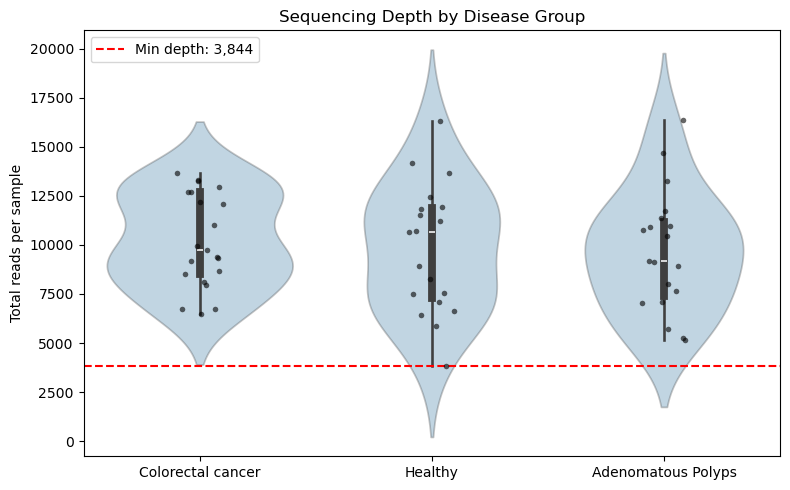

In [12]:
# === Cell 9: Visualize sequencing depth by disease group (corrected merge) ===
# Rationale: We identified that ASV table index matches metadata's 'host_disease'
# column, not 'SampleID'. Now we merge correctly and plot sequencing depth
# per group to check for technical bias.

seq_depth_df = pd.DataFrame({
    'host_disease': asv_table.index,
    'SequencingDepth': asv_table.sum(axis=1).values
})
seq_depth_df = seq_depth_df.merge(metadata[['host_disease', 'DiseaseStatus']], 
                                   on='host_disease')

# Violin + strip plot: shows distribution shape AND individual data points
fig, ax = plt.subplots(figsize=(8, 5))
sns.violinplot(data=seq_depth_df, x='DiseaseStatus', y='SequencingDepth', 
               alpha=0.3, ax=ax)
sns.stripplot(data=seq_depth_df, x='DiseaseStatus', y='SequencingDepth', 
              color='black', size=4, alpha=0.6, ax=ax)

# Horizontal line at minimum depth (rarefaction threshold)
ax.axhline(y=seq_depth_df['SequencingDepth'].min(), color='red', 
           linestyle='--', label=f"Min depth: {seq_depth_df['SequencingDepth'].min():,}")
ax.legend()
ax.set_title('Sequencing Depth by Disease Group')
ax.set_ylabel('Total reads per sample')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

In [13]:
# === Cell 10: Overall microbiome composition at Phylum level ===
# Rationale: Before diving into diversity metrics, we want a "big picture" view
# of what bacteria are in our samples. Phylum is the broadest useful level —
# there are only ~10 phyla vs 6,693 ASVs, making it easy to visualize.
# We convert raw counts to relative abundance (proportions that sum to 1)
# because raw counts are biased by sequencing depth.

# Step 1: Map each ASV to its Phylum using the taxonomy table
asv_to_phylum = taxonomy.set_index('ASV_sequence')['Phylum']

# Step 2: Rename ASV table columns from DNA sequences to Phylum names
# Multiple ASVs map to the same Phylum, so we group and sum them
phylum_table = asv_table.copy()
phylum_table.columns = phylum_table.columns.map(asv_to_phylum)
phylum_table = phylum_table.T.groupby(level=0).sum().T

# Step 3: Convert counts to relative abundance (proportions)
# Each row (sample) sums to 1.0 after this transformation
relative_abundance = phylum_table.div(phylum_table.sum(axis=1), axis=0)

print(f"Phylum table shape: {relative_abundance.shape}")
print(f"\nPhyla detected: {list(relative_abundance.columns)}")
print(f"\nFirst 3 samples (relative abundance):")
display(relative_abundance.head(3).round(3))

Phylum table shape: (59, 13)

Phyla detected: ['Actinobacteriota', 'Bacteroidota', 'Campylobacterota', 'Cyanobacteria', 'Desulfobacterota', 'Elusimicrobiota', 'Euryarchaeota', 'Firmicutes', 'Fusobacteriota', 'Patescibacteria', 'Proteobacteria', 'Synergistota', 'Verrucomicrobiota']

First 3 samples (relative abundance):


,Actinobacteriota,Bacteroidota,Campylobacterota,Cyanobacteria,Desulfobacterota,Elusimicrobiota,Euryarchaeota,Firmicutes,Fusobacteriota,Patescibacteria,Proteobacteria,Synergistota,Verrucomicrobiota
SampleID,,,,,,,,,,,,,
CRC1,0.022,0.0,0.000,0.004,0.0,0.006,0.000,0.796,0.004,0.0,0.086,0.0,0.081
CRC10,0.034,0.0,0.000,0.000,0.0,0.000,0.000,0.895,0.007,0.0,0.065,0.0,0.000
CRC11,0.020,0.0,0.002,0.004,0.0,0.000,0.003,0.389,0.034,0.0,0.543,0.0,0.005


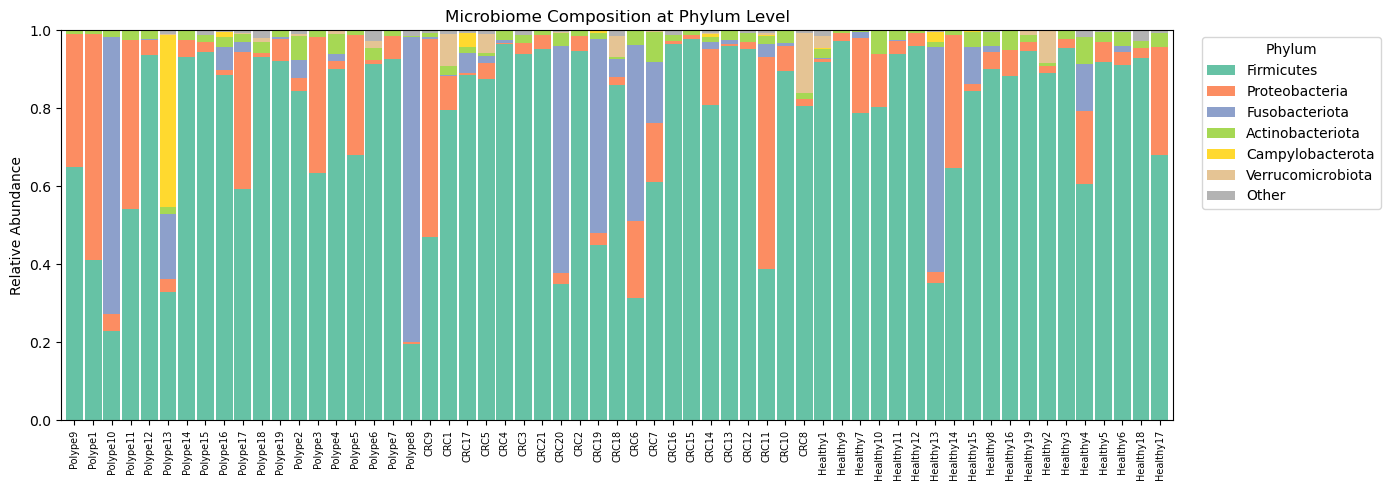


=== MEAN RELATIVE ABUNDANCE BY GROUP ===


,Firmicutes,Proteobacteria,Fusobacteriota,Actinobacteriota,Campylobacterota,Verrucomicrobiota
DiseaseStatus,,,,,,
Adenomatous Polyps,0.705,0.145,0.096,0.022,0.024,0.002
Colorectal cancer,0.769,0.095,0.090,0.021,0.002,0.017
Healthy,0.834,0.082,0.044,0.026,0.002,0.007


In [14]:
# === Cell 11: Stacked bar plot of phylum composition by disease group ===
# Rationale: This is the standard visualization in microbiome papers.
# Each bar is a sample, colored by phylum proportions.
# Samples are grouped by disease status so we can visually compare
# if certain phyla are more/less abundant in CRC vs Healthy.
# We keep only the top 6 phyla and group the rest as "Other"
# to keep the plot readable.

# Step 1: Keep top 6 phyla by mean abundance, group the rest as "Other"
mean_abundance = relative_abundance.mean().sort_values(ascending=False)
top_phyla = mean_abundance.head(6).index.tolist()

plot_df = relative_abundance[top_phyla].copy()
plot_df['Other'] = relative_abundance.drop(columns=top_phyla).sum(axis=1)

# Step 2: Add disease status and sort samples by group
plot_df['DiseaseStatus'] = plot_df.index.map(
    metadata.set_index('host_disease')['DiseaseStatus']
)
plot_df = plot_df.sort_values('DiseaseStatus')

# Step 3: Plot
fig, ax = plt.subplots(figsize=(14, 5))
disease_status = plot_df['DiseaseStatus']
plot_data = plot_df.drop(columns='DiseaseStatus')

plot_data.plot(kind='bar', stacked=True, ax=ax, width=0.9,
               colormap='Set2', edgecolor='none')

# Add group dividers and labels
ax.set_xlabel('')
ax.set_ylabel('Relative Abundance')
ax.set_title('Microbiome Composition at Phylum Level')
ax.legend(title='Phylum', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=7)
plt.tight_layout()
plt.show()

# Print mean abundance per group for the top phyla
print("\n=== MEAN RELATIVE ABUNDANCE BY GROUP ===")
summary = plot_df.groupby('DiseaseStatus')[top_phyla].mean().round(3)
display(summary)

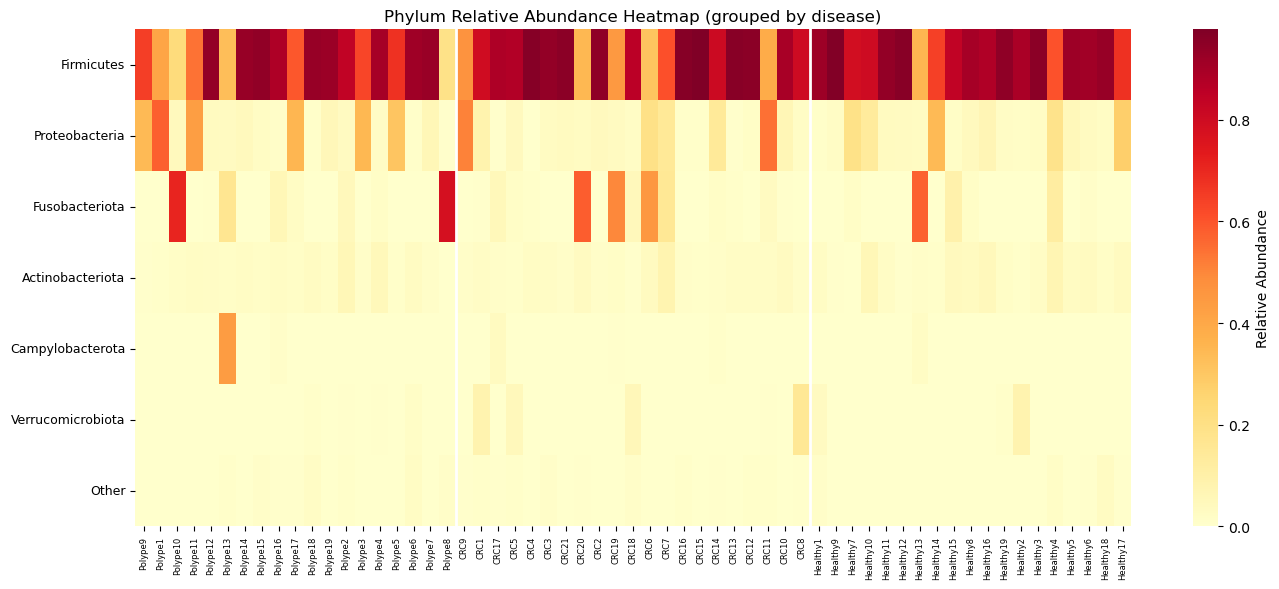

In [15]:
# === Cell 12: Heatmap of phylum composition by disease group ===
# Rationale: Heatmaps make it easier to spot patterns across many samples
# compared to stacked bars. Color intensity represents abundance —
# darker = more abundant. Samples are grouped by disease status
# so patterns between groups become visually obvious.

fig, ax = plt.subplots(figsize=(14, 6))

# Reuse plot_df from previous cell, sorted by disease group
heatmap_data = plot_df.drop(columns='DiseaseStatus').T

sns.heatmap(heatmap_data, cmap='YlOrRd', ax=ax,
            xticklabels=True, yticklabels=True,
            cbar_kws={'label': 'Relative Abundance'})

ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=6)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=9)
ax.set_title('Phylum Relative Abundance Heatmap (grouped by disease)')
ax.set_xlabel('')

# Add vertical lines to separate disease groups
groups = plot_df['DiseaseStatus'].values if 'DiseaseStatus' in plot_df.columns else disease_status.values
group_changes = [i for i in range(1, len(groups)) if groups[i] != groups[i-1]]
for line in group_changes:
    ax.axvline(x=line, color='white', linewidth=2)

plt.tight_layout()
plt.show()

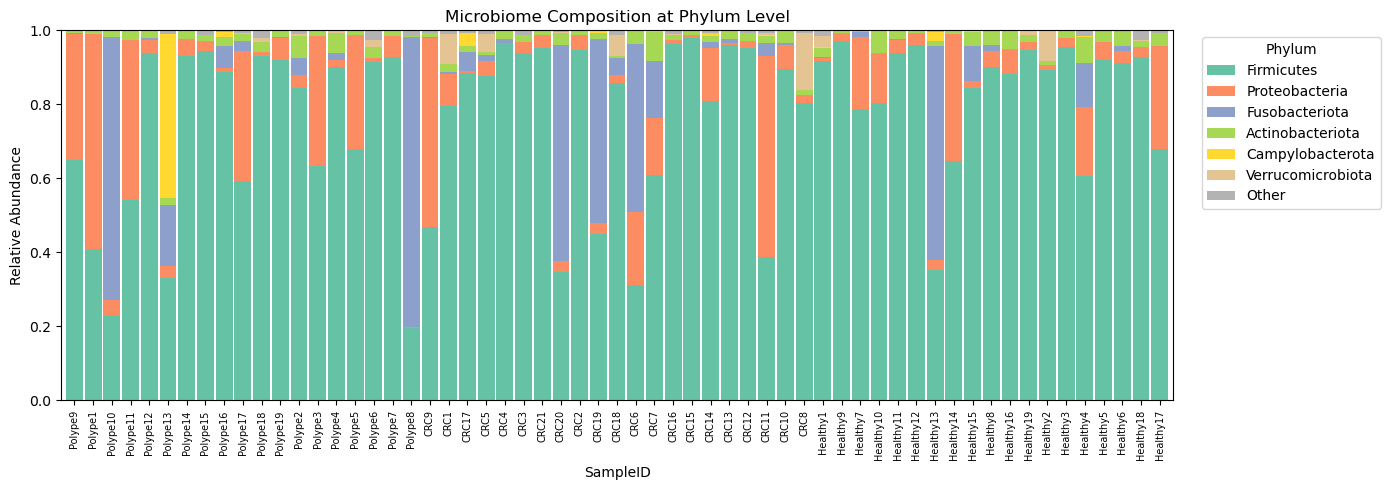

Saved: figures/phylum_composition_barplot.png


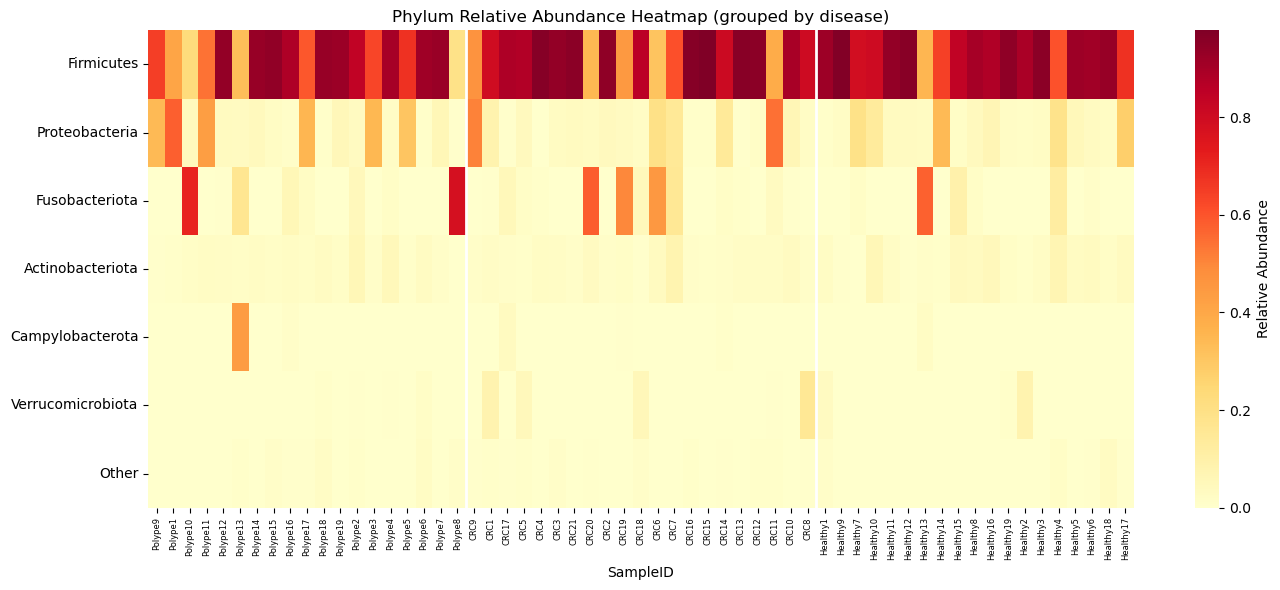

Saved: figures/phylum_heatmap.png


In [16]:
# === Cell 13: Save key figures and summarize notebook findings ===
# Rationale: Saving figures to the figures/ folder serves two purposes:
# 1. They can be referenced in the README for the GitHub repo
# 2. They persist even if notebook outputs are cleared

# Recreate and save the composition barplot
fig, ax = plt.subplots(figsize=(14, 5))
plot_data = plot_df.drop(columns='DiseaseStatus')
plot_data.plot(kind='bar', stacked=True, ax=ax, width=0.9,
               colormap='Set2', edgecolor='none')
ax.set_ylabel('Relative Abundance')
ax.set_title('Microbiome Composition at Phylum Level')
ax.legend(title='Phylum', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=7)
plt.tight_layout()
fig.savefig('../figures/phylum_composition_barplot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/phylum_composition_barplot.png")

# Recreate and save the heatmap
fig, ax = plt.subplots(figsize=(14, 6))
heatmap_data = plot_df.drop(columns='DiseaseStatus').T
sns.heatmap(heatmap_data, cmap='YlOrRd', ax=ax,
            xticklabels=True, yticklabels=True,
            cbar_kws={'label': 'Relative Abundance'})
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=6)
ax.set_title('Phylum Relative Abundance Heatmap (grouped by disease)')
groups = disease_status.values
group_changes = [i for i in range(1, len(groups)) if groups[i] != groups[i-1]]
for line in group_changes:
    ax.axvline(x=line, color='white', linewidth=2)
plt.tight_layout()
fig.savefig('../figures/phylum_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/phylum_heatmap.png")